# 🏭 스마트 창고 출고 지연 예측 - v4 (래그 피처 추가)

## 핵심 개선: 시나리오 내 시계열 구조 활용
- 각 시나리오 = 25 타임슬롯(15분 간격, 약 6시간)
- **t-1 래그 피처**: 직전 시점 값이 현재 예측에 매우 강력
- GroupKFold(scenario_id): 시나리오 단위로 train/val 분리 (LB와 동일한 조건)

## 1. 라이브러리 설정

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import warnings
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLDS = 5
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

np.random.seed(SEED)
print('✅ 환경 설정 완료')

✅ 환경 설정 완료


## 2. 데이터 로드 및 병합

In [4]:
train  = pd.read_csv('./data/train.csv')
test   = pd.read_csv('./data/test.csv')
layout = pd.read_csv('./data/layout_info.csv')

# layout_type 인코딩
layout_type_map = {v: i for i, v in enumerate(layout['layout_type'].unique())}
layout['layout_type_enc'] = layout['layout_type'].map(layout_type_map)

# layout 병합
train = train.merge(layout.drop(columns=['layout_type']), on='layout_id', how='left')
test  = test.merge(layout.drop(columns=['layout_type']),  on='layout_id', how='left')

print(f'train: {train.shape}, test: {test.shape}')
print(f'시나리오 수 - train: {train["scenario_id"].nunique()}, test: {test["scenario_id"].nunique()}')

train: (250000, 108), test: (50000, 107)
시나리오 수 - train: 10000, test: 2000


## 3. 타겟 분석

In [5]:
print('=== 타겟 통계 ===')
print(train[TARGET].describe())
print(f'\n왜도: {stats.skew(train[TARGET]):.4f}')
print(f'log1p 변환 후 왜도: {stats.skew(np.log1p(train[TARGET])):.4f}')

# 타임슬롯 구조 확인
slots_per_scenario = train.groupby('scenario_id').size()
print(f'\n시나리오당 타임슬롯: min={slots_per_scenario.min()}, max={slots_per_scenario.max()}, mean={slots_per_scenario.mean():.1f}')

=== 타겟 통계 ===
count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64

왜도: 5.6820
log1p 변환 후 왜도: 0.0801

시나리오당 타임슬롯: min=25, max=25, mean=25.0


## 4. 피처 엔지니어링

In [6]:
def engineer_features(df):
    d = df.copy()

    # ── ① 로봇 압박
    d['charge_pressure']       = d['charge_queue_length'] / (d['charger_count'] + 1)
    d['active_robot_ratio']    = d['robot_active'] / (d['robot_total'] + 1)
    d['idle_robot_ratio']      = d['robot_idle'] / (d['robot_total'] + 1)
    d['low_batt_robot_count']  = d['low_battery_ratio'] * d['robot_active']
    d['battery_stress']        = (1 - d['battery_mean'] / 100) * d['battery_std']
    d['charge_inefficiency']   = (100 - d['charge_efficiency_pct']) / 100
    d['effective_robot_avail'] = d['robot_total'] - d['low_batt_robot_count'] - d['charge_queue_length']
    d['robot_fault_ratio']     = d['fault_count_15m'] / (d['robot_active'] + 1)

    # ── ② 병목 복합 지수
    d['incident_total_15m']    = d['blocked_path_15m'] + d['near_collision_15m'] + d['fault_count_15m']
    d['congestion_load']       = d['congestion_score'] * d['avg_trip_distance']
    d['wait_per_intersection'] = d['intersection_wait_time_avg'] / (d['intersection_count'] + 1)
    d['path_congestion_gap']   = d['path_optimization_score'] - d['congestion_score']
    d['aisle_density']         = d['aisle_traffic_score'] / (d['aisle_width_avg'] + 0.1)
    d['oneway_congestion']     = d['one_way_ratio'] * d['congestion_score']
    d['compact_congestion']    = d['layout_compactness'] * d['congestion_score']

    # ── ③ 주문 부하
    d['order_complexity']      = d['unique_sku_15m'] * d['avg_items_per_order']
    d['urgent_heavy_ratio']    = d['urgent_order_ratio'] * d['heavy_item_ratio']
    d['effective_order_load']  = d['order_inflow_15m'] * (1 + d['urgent_order_ratio'])
    d['rework_pressure']       = d['return_order_ratio'] + d['replenishment_overlap']
    d['forecast_miss']         = 1 - d['daily_forecast_accuracy']
    d['pick_complexity']       = d['pick_list_length_avg'] * (1 - d['sku_concentration'])
    d['backorder_urgency']     = d['backorder_ratio'] * d['urgent_order_ratio']

    # ── ④ 설비 압박
    d['dock_pack_util_avg']      = (d['pack_utilization'] + d['loading_dock_util'] + d['staging_area_util']) / 3
    d['orders_per_pack_station'] = d['order_inflow_15m'] / (d['pack_station_count'] + 1)
    d['orders_per_robot']        = d['order_inflow_15m'] / (d['robot_active'] + 1)
    d['robot_density']           = d['robot_total'] / (d['floor_area_sqm'] + 1)
    d['charger_robot_ratio']     = d['charger_count'] / (d['robot_total'] + 1)
    d['pack_area_pressure']      = d['pack_utilization'] * d['layout_compactness']
    d['dock_truck_bottleneck']   = d['loading_dock_util'] * d['outbound_truck_wait_min']

    # ── ⑤ 환경·시스템
    d['temp_diff']             = abs(d['warehouse_temp_avg'] - d['external_temp_c'])
    d['heat_humidity_index']   = d['warehouse_temp_avg'] * d['humidity_pct'] / 100
    d['it_bottleneck']         = d['wms_response_time_ms'] * (1 + d['scanner_error_rate'])
    d['network_instability']   = d['network_latency_ms'] * (1 - d['wifi_signal_db'] / 100)
    d['barcode_fail_rate']     = 1 - d['barcode_read_success_rate']
    d['label_scan_bottleneck'] = d['label_print_queue'] * (1 + d['scanner_error_rate'])
    d['conveyor_load']         = d['avg_package_weight_kg'] / (d['conveyor_speed_mps'] + 0.01)

    # ── ⑥ 인력
    d['orders_per_staff']      = d['order_inflow_15m'] / (d['staff_on_floor'] + 1)
    d['forklift_staff_ratio']  = d['forklift_active_count'] / (d['staff_on_floor'] + 1)
    d['shift_load_ratio']      = d['order_inflow_15m'] / (d['prev_shift_volume'] + 1)
    d['handover_pressure']     = d['shift_handover_delay_min'] * d['prev_shift_volume'] / 1000
    d['skilled_capacity']      = d['staff_on_floor'] * d['worker_avg_tenure_months']

    # ── ⑦ 시간 주기성
    d['shift_hour_sin']        = np.sin(2 * np.pi * d['shift_hour'] / 24)
    d['shift_hour_cos']        = np.cos(2 * np.pi * d['shift_hour'] / 24)
    d['dow_sin']               = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos']               = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['is_peak_hour']          = d['shift_hour'].isin([9,10,11,14,15,16,17]).astype(int)

    # ── ⑧ 레이아웃
    d['age_maintenance_risk']    = d['building_age_years'] * (1 - d['maintenance_schedule_score'])
    d['vertical_gap']            = d['ceiling_height_m'] - d['racking_height_avg_m']
    d['dispersion_trip_cost']    = d['zone_dispersion'] * d['avg_trip_distance']
    d['crossdock_dock_pressure'] = d['cross_dock_ratio'] * d['loading_dock_util']
    d['cold_chain_risk']         = d['cold_chain_ratio'] * abs(d['cold_storage_temp_c'] + 18)
    d['area_per_robot']          = d['floor_area_sqm'] / (d['robot_total'] + 1)

    # ── ⑨ 교호작용
    d['robot_order_congestion']  = d['orders_per_robot'] * d['congestion_score']
    d['battery_order_pressure']  = d['battery_stress'] * d['effective_order_load']
    d['it_order_bottleneck']     = d['it_bottleneck'] * d['order_inflow_15m'] / 1000
    d['super_traffic_jam_risk']  = d['sku_concentration'] * d['avg_trip_distance'] * d['layout_compactness']

    return d


train_fe = engineer_features(train)
test_fe  = engineer_features(test)
print(f'피처 엔지니어링 완료: {train_fe.shape}')

피처 엔지니어링 완료: (250000, 164)


## 5. 🔑 핵심: 래그 피처 (시나리오 내 시계열 구조 활용)

In [7]:
# 래그 피처를 만들 핵심 컬럼 선택
LAG_COLS = [
    'order_inflow_15m', 'congestion_score', 'robot_active', 'robot_utilization',
    'battery_mean', 'charge_queue_length', 'blocked_path_15m', 'fault_count_15m',
    'pack_utilization', 'loading_dock_util', 'effective_order_load',
    'congestion_load', 'charge_pressure', 'orders_per_robot',
    'it_bottleneck', 'battery_stress',
]

def add_lag_features(df, lag_cols, is_train=True):
    """
    시나리오 내에서 t-1, t-2 래그 피처 생성
    시나리오 경계를 넘지 않도록 shift 후 NaN 처리
    """
    d = df.copy()
    # scenario_id + shift_hour 기준 정렬 (타임슬롯 순서 보장)
    d = d.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)

    for col in lag_cols:
        if col not in d.columns:
            continue
        # t-1 래그
        lag1 = d.groupby('scenario_id')[col].shift(1)
        d[f'{col}_lag1'] = lag1

        # t-2 래그
        lag2 = d.groupby('scenario_id')[col].shift(2)
        d[f'{col}_lag2'] = lag2

        # t-1 대비 변화량 (diff)
        d[f'{col}_diff1'] = d[col] - lag1

    # 래그 NaN → 같은 시나리오 내 중앙값으로 대체
    lag_feat_cols = [c for c in d.columns if '_lag' in c or '_diff' in c]
    for col in lag_feat_cols:
        d[col] = d.groupby('scenario_id')[col].transform(lambda x: x.fillna(x.median()))
    
    return d


train_fe = add_lag_features(train_fe, LAG_COLS, is_train=True)
test_fe  = add_lag_features(test_fe,  LAG_COLS, is_train=False)

lag_feature_count = len([c for c in train_fe.columns if '_lag' in c or '_diff' in c])
print(f'래그 피처 추가: {lag_feature_count}개')
print(f'전체 피처 수: {len([c for c in train_fe.columns if c not in ID_COLS + [TARGET]])}개')

래그 피처 추가: 49개
전체 피처 수: 208개


## 6. CV 기반 타겟 인코딩

In [8]:
from sklearn.model_selection import KFold

def target_encode_cv(train_df, test_df, col, target, n_splits=5, alpha=20):
    """fold 밖 데이터로만 인코딩 (leakage 방지)"""
    global_mean = train_df[target].mean()
    train_enc   = np.zeros(len(train_df))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for tr_i, val_i in kf.split(train_df):
        stats_map = train_df.iloc[tr_i].groupby(col)[target].agg(['mean','count'])
        stats_map['smooth'] = (
            (stats_map['count'] * stats_map['mean'] + alpha * global_mean)
            / (stats_map['count'] + alpha)
        )
        train_enc[val_i] = train_df.iloc[val_i][col].map(stats_map['smooth']).fillna(global_mean)

    full_stats = train_df.groupby(col)[target].agg(['mean','count'])
    full_stats['smooth'] = (
        (full_stats['count'] * full_stats['mean'] + alpha * global_mean)
        / (full_stats['count'] + alpha)
    )
    test_enc = test_df[col].map(full_stats['smooth']).fillna(global_mean).values
    return train_enc, test_enc


# layout_id 타겟 인코딩
te_tr, te_te = target_encode_cv(train_fe, test_fe, 'layout_id', TARGET)
train_fe['te_layout_id'] = te_tr
test_fe['te_layout_id']  = te_te

# layout_type_enc 타겟 인코딩
te_tr, te_te = target_encode_cv(train_fe, test_fe, 'layout_type_enc', TARGET)
train_fe['te_layout_type'] = te_tr
test_fe['te_layout_type']  = te_te

print('✅ 타겟 인코딩 완료')

✅ 타겟 인코딩 완료


## 7. 학습 준비

In [9]:
feature_cols = [c for c in train_fe.columns if c not in ID_COLS + [TARGET]]

# 결측치 처리
for col in feature_cols:
    med = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(med)
    test_fe[col]  = test_fe[col].fillna(med)

X      = train_fe[feature_cols].copy()
y      = train_fe[TARGET].copy()          # 원본 타겟
X_test = test_fe[feature_cols].copy()

# log 변환 (왜도 5.68 처리)
y_tr_all = np.log1p(y.clip(lower=0))

def decode_pred(pred):
    return np.expm1(pred).clip(0)

# GroupKFold: 시나리오 단위 분할 (LB와 동일 조건)
gkf    = GroupKFold(n_splits=N_FOLDS)
groups = train_fe['scenario_id']

print(f'피처 수: {len(feature_cols)}')
print(f'  - 래그/diff 피처: {len([c for c in feature_cols if "_lag" in c or "_diff" in c])}개')
print(f'  - 타겟인코딩:      {len([c for c in feature_cols if "te_" in c])}개')

피처 수: 210
  - 래그/diff 피처: 49개
  - 타겟인코딩:      3개


## 8. Optuna 하이퍼파라미터 튜닝 (LightGBM)

In [10]:
# 튜닝용 샘플링 (50K, log 변환 타겟)
tune_idx    = np.random.choice(len(X), 50000, replace=False)
X_tune      = X.iloc[tune_idx].reset_index(drop=True)
y_tune      = y_tr_all.iloc[tune_idx].reset_index(drop=True)  # log 변환
groups_tune = groups.iloc[tune_idx].reset_index(drop=True)

def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators',      500, 3000),
        learning_rate     = trial.suggest_float('learning_rate',   0.01, 0.1, log=True),
        max_depth         = trial.suggest_int('max_depth',         4, 8),
        num_leaves        = trial.suggest_int('num_leaves',        31, 127),
        subsample         = trial.suggest_float('subsample',       0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree',0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha',       1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',      1e-4, 10.0, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 20, 150),
    )
    FIXED = dict(device='gpu', random_state=SEED, verbose=-1)
    gkf3  = GroupKFold(n_splits=3)
    maes  = []
    for tr_i, val_i in gkf3.split(X_tune, y_tune, groups=groups_tune):
        model = LGBMRegressor(**params, **FIXED)
        model.fit(
            X_tune.iloc[tr_i], y_tune.iloc[tr_i],
            eval_set=[(X_tune.iloc[val_i], y_tune.iloc[val_i])],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        pred = decode_pred(model.predict(X_tune.iloc[val_i]))
        true = decode_pred(y_tune.iloc[val_i].values)
        maes.append(mean_absolute_error(true, pred))
    return np.mean(maes)

print('🔍 LightGBM Optuna 튜닝 (50 trials)...')
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

BEST_LGB = study_lgb.best_params
print(f'\n✅ 최적 MAE: {study_lgb.best_value:.4f}')
print(f'   파라미터: {BEST_LGB}')

🔍 LightGBM Optuna 튜닝 (50 trials)...


Best trial: 31. Best value: 9.11804: 100%|██████████| 50/50 [18:49<00:00, 22.60s/it]


✅ 최적 MAE: 9.1180
   파라미터: {'n_estimators': 2280, 'learning_rate': 0.012285140368651724, 'max_depth': 7, 'num_leaves': 94, 'subsample': 0.9612705073316815, 'colsample_bytree': 0.5386828976078983, 'reg_alpha': 0.4143475757681107, 'reg_lambda': 0.0002615801120394464, 'min_child_samples': 71}


## 9. LightGBM 5-Fold 학습

In [11]:
oof_lgb        = np.zeros(len(X))
test_lgb       = np.zeros(len(X_test))
lgb_importances= np.zeros(len(feature_cols))
fold_maes_lgb  = []
FIXED = dict(device='gpu', random_state=SEED, verbose=-1)

print('🚀 LightGBM 5-Fold 학습\n')
for fold, (tr_i, val_i) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1}/{N_FOLDS} ──')
    X_tr, y_tr   = X.iloc[tr_i], y_tr_all.iloc[tr_i]
    X_val, y_val = X.iloc[val_i], y_tr_all.iloc[val_i]

    model = LGBMRegressor(**BEST_LGB, **FIXED)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)]
    )

    oof_lgb[val_i]   = decode_pred(model.predict(X_val))
    test_lgb        += decode_pred(model.predict(X_test)) / N_FOLDS
    lgb_importances += model.feature_importances_ / N_FOLDS

    mae = mean_absolute_error(decode_pred(y_val.values), oof_lgb[val_i])
    fold_maes_lgb.append(mae)
    print(f'   MAE: {mae:.4f}\n')

lgb_oof_mae = mean_absolute_error(y, oof_lgb)
print(f'📊 LightGBM OOF MAE: {lgb_oof_mae:.4f}  (베이스라인 대비: {9.2405-lgb_oof_mae:+.4f})')

🚀 LightGBM 5-Fold 학습

── Fold 1/5 ──
[200]	valid_0's l2: 0.450378
[400]	valid_0's l2: 0.43942
   MAE: 9.1155

── Fold 2/5 ──
[200]	valid_0's l2: 0.461958
[400]	valid_0's l2: 0.450987
[600]	valid_0's l2: 0.450401
   MAE: 8.9870

── Fold 3/5 ──
[200]	valid_0's l2: 0.48318
[400]	valid_0's l2: 0.472345
[600]	valid_0's l2: 0.470448
[800]	valid_0's l2: 0.469763
   MAE: 9.5878

── Fold 4/5 ──
[200]	valid_0's l2: 0.421472
[400]	valid_0's l2: 0.408191
[600]	valid_0's l2: 0.407243
   MAE: 8.4920

── Fold 5/5 ──
[200]	valid_0's l2: 0.437067
[400]	valid_0's l2: 0.42641
[600]	valid_0's l2: 0.425496
   MAE: 8.9067

📊 LightGBM OOF MAE: 9.0178  (베이스라인 대비: +0.2227)


## 10. CatBoost 5-Fold 학습

In [12]:
oof_cb       = np.zeros(len(X))
test_cb      = np.zeros(len(X_test))
fold_maes_cb = []

print('🐱 CatBoost 5-Fold 학습\n')
for fold, (tr_i, val_i) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1}/{N_FOLDS} ──')
    X_tr, y_tr   = X.iloc[tr_i], y_tr_all.iloc[tr_i]
    X_val, y_val = X.iloc[val_i], y_tr_all.iloc[val_i]

    model = CatBoostRegressor(
        iterations=3000, learning_rate=0.03, depth=8,
        l2_leaf_reg=5.0, bootstrap_type='Bernoulli', subsample=0.8,
        random_seed=SEED, eval_metric='MAE',
        early_stopping_rounds=50, verbose=200,
        task_type='GPU', devices='0',
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    oof_cb[val_i]  = decode_pred(model.predict(X_val))
    test_cb       += decode_pred(model.predict(X_test)) / N_FOLDS

    mae = mean_absolute_error(decode_pred(y_val.values), oof_cb[val_i])
    fold_maes_cb.append(mae)
    print(f'   MAE: {mae:.4f}\n')

cb_oof_mae = mean_absolute_error(y, oof_cb)
print(f'📊 CatBoost OOF MAE: {cb_oof_mae:.4f}  (베이스라인 대비: {9.2405-cb_oof_mae:+.4f})')

🐱 CatBoost 5-Fold 학습

── Fold 1/5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.8655863	test: 0.8686541	best: 0.8686541 (0)	total: 16.5ms	remaining: 49.6s
200:	learn: 0.4647804	test: 0.4787440	best: 0.4787440 (200)	total: 1.67s	remaining: 23.2s
400:	learn: 0.4462146	test: 0.4754972	best: 0.4754701 (398)	total: 3.34s	remaining: 21.6s
600:	learn: 0.4311263	test: 0.4748129	best: 0.4747911 (596)	total: 5s	remaining: 19.9s
800:	learn: 0.4180807	test: 0.4741774	best: 0.4741341 (773)	total: 6.67s	remaining: 18.3s
bestTest = 0.4741340625
bestIteration = 773
Shrink model to first 774 iterations.
   MAE: 9.1713

── Fold 2/5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.8664001	test: 0.8653212	best: 0.8653212 (0)	total: 9.17ms	remaining: 27.5s
200:	learn: 0.4647302	test: 0.4770378	best: 0.4770378 (200)	total: 1.64s	remaining: 22.9s
400:	learn: 0.4457966	test: 0.4750445	best: 0.4750048 (353)	total: 3.42s	remaining: 22.2s
bestTest = 0.4746659375
bestIteration = 496
Shrink model to first 497 iterations.
   MAE: 9.0235

── Fold 3/5 ──


...

0:	learn: 0.8665645	test: 0.8614751	best: 0.8614751 (0)	total: 9.32ms	remaining: 28s
200:	learn: 0.4612447	test: 0.4952776	best: 0.4952776 (200)	total: 1.82s	remaining: 25.4s
400:	learn: 0.4430250	test: 0.4915361	best: 0.4915353 (399)	total: 3.62s	remaining: 23.5s
600:	learn: 0.4282445	test: 0.4902675	best: 0.4902636 (599)	total: 5.38s	remaining: 21.5s
bestTest = 0.4896409766
bestIteration = 749
Shrink model to first 750 iterations.
   MAE: 9.5972

── Fold 4/5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.8656042	test: 0.8692065	best: 0.8692065 (0)	total: 9.68ms	remaining: 29s
200:	learn: 0.4677832	test: 0.4680833	best: 0.4680833 (200)	total: 1.85s	remaining: 25.7s
400:	learn: 0.4489856	test: 0.4640727	best: 0.4640727 (400)	total: 3.72s	remaining: 24.1s
600:	learn: 0.4338114	test: 0.4627782	best: 0.4627750 (599)	total: 5.55s	remaining: 22.2s
bestTest = 0.4625454688
bestIteration = 725
Shrink model to first 726 iterations.
   MAE: 8.5238

── Fold 5/5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.8660906	test: 0.8660980	best: 0.8660980 (0)	total: 9.88ms	remaining: 29.6s
200:	learn: 0.4669570	test: 0.4701019	best: 0.4701019 (200)	total: 1.76s	remaining: 24.5s
400:	learn: 0.4480483	test: 0.4672993	best: 0.4672993 (400)	total: 3.58s	remaining: 23.2s
600:	learn: 0.4322425	test: 0.4665731	best: 0.4665731 (600)	total: 5.44s	remaining: 21.7s
800:	learn: 0.4187297	test: 0.4662851	best: 0.4661336 (772)	total: 7.28s	remaining: 20s
bestTest = 0.4661336328
bestIteration = 772
Shrink model to first 773 iterations.
   MAE: 8.9294

📊 CatBoost OOF MAE: 9.0490  (베이스라인 대비: +0.1915)


## 11. XGBoost 5-Fold 학습

In [13]:
oof_xgb       = np.zeros(len(X))
test_xgb      = np.zeros(len(X_test))
fold_maes_xgb = []

print('⚡ XGBoost 5-Fold 학습\n')
for fold, (tr_i, val_i) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1}/{N_FOLDS} ──')
    X_tr, y_tr   = X.iloc[tr_i], y_tr_all.iloc[tr_i]
    X_val, y_val = X.iloc[val_i], y_tr_all.iloc[val_i]

    model = XGBRegressor(
        n_estimators=3000, learning_rate=0.03,
        max_depth=7, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        tree_method='hist', device='cuda',
        random_state=SEED, verbosity=0,
        early_stopping_rounds=100, eval_metric='mae',
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=200)

    oof_xgb[val_i]  = decode_pred(model.predict(X_val))
    test_xgb       += decode_pred(model.predict(X_test)) / N_FOLDS

    mae = mean_absolute_error(decode_pred(y_val.values), oof_xgb[val_i])
    fold_maes_xgb.append(mae)
    print(f'   MAE: {mae:.4f}\n')

xgb_oof_mae = mean_absolute_error(y, oof_xgb)
print(f'📊 XGBoost OOF MAE: {xgb_oof_mae:.4f}  (베이스라인 대비: {9.2405-xgb_oof_mae:+.4f})')

⚡ XGBoost 5-Fold 학습

── Fold 1/5 ──
[0]	validation_0-mae:0.86772
[200]	validation_0-mae:0.47062
[333]	validation_0-mae:0.47092
   MAE: 9.1177

── Fold 2/5 ──
[0]	validation_0-mae:0.86439
[200]	validation_0-mae:0.47224
[307]	validation_0-mae:0.47266
   MAE: 8.9835

── Fold 3/5 ──
[0]	validation_0-mae:0.86045
[200]	validation_0-mae:0.48972
[390]	validation_0-mae:0.48986
   MAE: 9.5833

── Fold 4/5 ──
[0]	validation_0-mae:0.86803
[200]	validation_0-mae:0.46058
[398]	validation_0-mae:0.46034
   MAE: 8.4899

── Fold 5/5 ──
[0]	validation_0-mae:0.86521
[200]	validation_0-mae:0.46464
[289]	validation_0-mae:0.46478
   MAE: 8.9053

📊 XGBoost OOF MAE: 9.0159  (베이스라인 대비: +0.2246)


## 12. 앙상블 & 결과

In [14]:
def ensemble_loss(weights):
    w1, w2, w3 = weights
    blend = w1 * oof_lgb + w2 * oof_cb + w3 * oof_xgb
    return mean_absolute_error(y, blend)

result = minimize(
    ensemble_loss, [1/3, 1/3, 1/3], method='SLSQP',
    bounds=[(0,1)]*3,
    constraints={'type':'eq', 'fun': lambda w: sum(w)-1}
)
w_lgb, w_cb, w_xgb = result.x
best_mae = result.fun

print(f'⚖️  앙상블 가중치: LGB={w_lgb:.3f}, CB={w_cb:.3f}, XGB={w_xgb:.3f}')
print(f'\n{"="*50}')
print(f'  베이스라인  : 9.2405')
print(f'  LightGBM   : {lgb_oof_mae:.4f}  ({9.2405-lgb_oof_mae:+.4f})')
print(f'  CatBoost   : {cb_oof_mae:.4f}  ({9.2405-cb_oof_mae:+.4f})')
print(f'  XGBoost    : {xgb_oof_mae:.4f}  ({9.2405-xgb_oof_mae:+.4f})')
print(f'  앙상블      : {best_mae:.4f}  ({9.2405-best_mae:+.4f})')
print(f'{"="*50}')

⚖️  앙상블 가중치: LGB=0.259, CB=0.276, XGB=0.465

  베이스라인  : 9.2405
  LightGBM   : 9.0178  (+0.2227)
  CatBoost   : 9.0490  (+0.1915)
  XGBoost    : 9.0159  (+0.2246)
  앙상블      : 9.0039  (+0.2366)


## 13. 피처 중요도

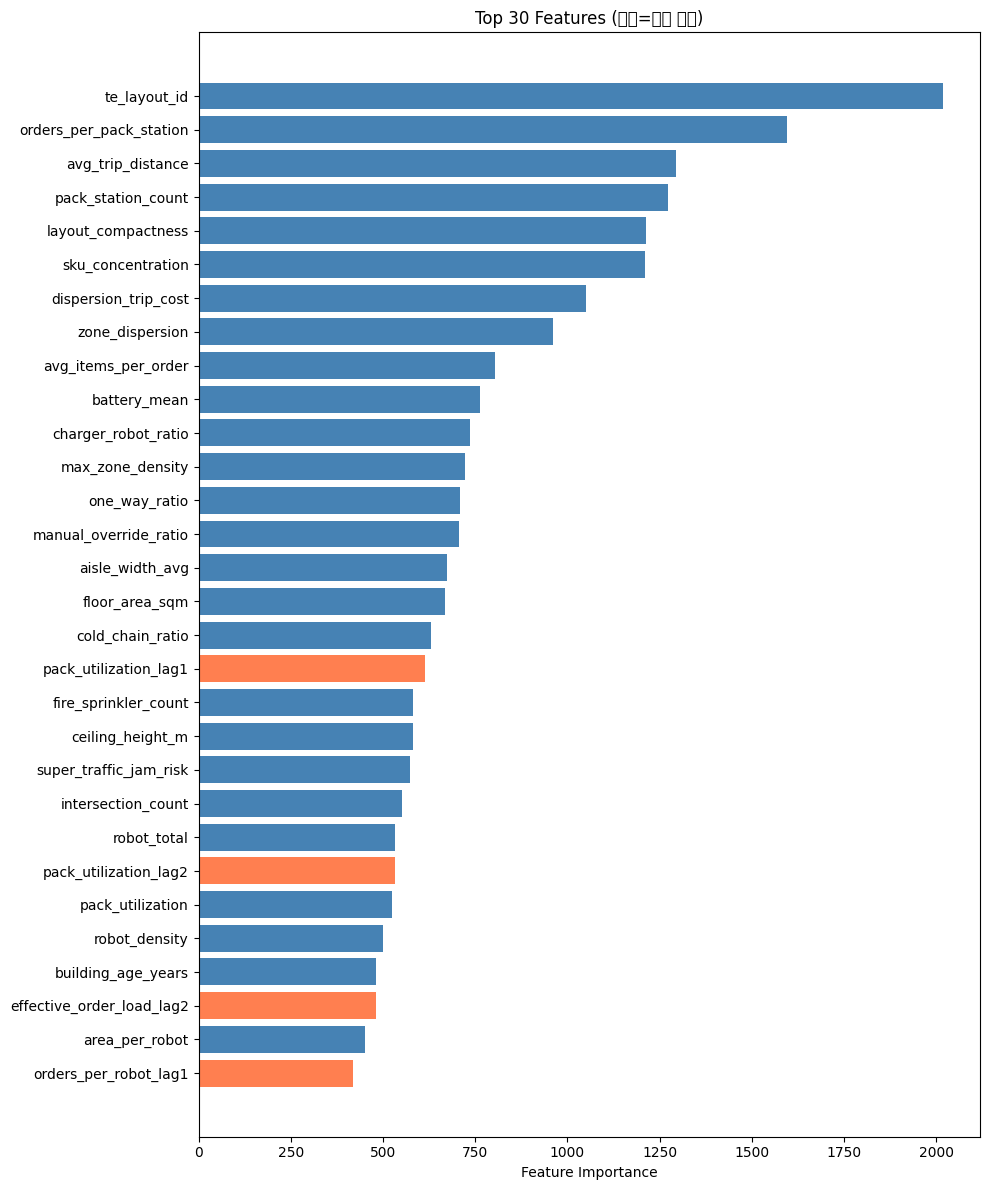

Top 10:
                feature  importance
           te_layout_id      2017.8
orders_per_pack_station      1594.8
      avg_trip_distance      1293.4
     pack_station_count      1273.2
     layout_compactness      1213.4
      sku_concentration      1210.8
   dispersion_trip_cost      1049.8
        zone_dispersion       961.0
    avg_items_per_order       803.6
           battery_mean       763.4


In [15]:
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': lgb_importances})\
           .sort_values('importance', ascending=False).reset_index(drop=True)

top30 = imp_df.head(30)
is_lag = top30['feature'].str.contains('_lag|_diff')
colors = is_lag.map({True: 'coral', False: 'steelblue'})

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(top30['feature'][::-1], top30['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 30 Features (주황=래그 피처)')
plt.tight_layout()
plt.savefig('./feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10:')
print(imp_df.head(10)[['feature','importance']].to_string(index=False))

## 14. 제출 파일 생성

In [17]:
final_preds = (w_lgb * test_lgb + w_cb * test_cb + w_xgb * test_xgb).clip(0)

pred_df    = pd.DataFrame({'ID': test_fe['ID'], TARGET: final_preds})
submission = pd.read_csv('./data/sample_submission.csv')
submission = submission.drop(columns=[TARGET], errors='ignore')
submission = pd.merge(submission, pred_df, on='ID', how='left')
submission.to_csv('./submission_v4.csv', index=False)

print('✅ submission_v4.csv 저장 완료')
print(f'\n예측값 분포:')
print(submission[TARGET].describe())

✅ submission_v4.csv 저장 완료

예측값 분포:
count    50000.000000
mean        17.785809
std         13.130099
min          0.004107
25%          5.226881
50%         13.357101
75%         32.368656
max         51.112829
Name: avg_delay_minutes_next_30m, dtype: float64
